# The Silicon Canary \U0001F9EB
### Chips go into everything — so do chip stocks turn first?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

Semiconductors are the first thing anyone cancels and the first thing anyone orders, so the
sector is supposed to lead the cycle — and, the story goes, the market. This notebook tests it
properly, which mostly means refusing to be impressed by the fact that a tech-heavy sector fund
moves with the market.

> \U0001F4D3 **This is the plain-language layer.** The residual construction, the HAC
> regressions and the multiplicity count are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do semis move with the market? | Overwhelmingly — about 80% correlated. That is not the claim. |
| Do they move *first*? | A little, at one day, once the shared factor is removed. |
| Is it bigger than the reverse? | Barely. And the tech control scores nearly as well, which is the problem. |
| Can you trade it? | The rule sits in cash a third of the time and gives up return for a smaller drawdown. |

## 1 · The claim

> *"Watch the semis. They roll over before the index does — every cycle."*

The economic story is real: chip orders are cyclical and early. Whether that shows up in
*prices*, after everyone already knows the story, is a different question.

In [2]:
from semi_lead import data, strategy as st

px = data.load_prices()
rets = st.to_returns(px)
common = rets[list(data.TICKERS)].dropna()
print(f"as-of {data.AS_OF} | common window {common.index[0].date()} -> "
      f"{common.index[-1].date()} ({len(common):,} sessions)")
print(f"raw correlation {data.CANARY} vs {data.MARKET}: "
      f"{common[data.CANARY].corr(common[data.MARKET]):.3f}")
resid = st.residual_series(common, data.CANARY, data.MARKET).dropna()
print(f"after removing a rolling beta: "
      f"{resid.corr(common[data.MARKET].reindex(resid.index)):+.3f}")

as-of 2026-06-30 | common window 2007-05-31 -> 2026-06-30 (4,801 sessions)
raw correlation SMH vs SPY: 0.791
after removing a rolling beta: +0.003


Look at those two numbers. Raw, the canary is inseparable from the market. Everything below
uses the residual — the part of the semiconductor return the market cannot explain.

## 2 · Lead-lag, and its mirror

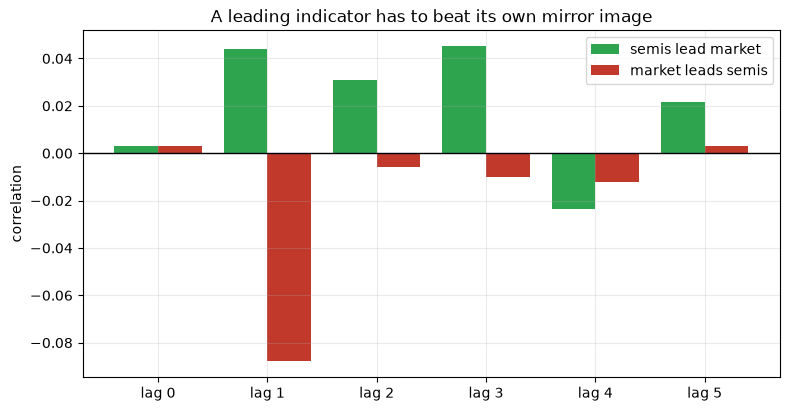

,sector_leads,market_leads,difference
lag,,,
0,0.0031,0.0031,0.0000
1,0.0440,-0.0878,0.1318
2,0.0310,-0.0059,0.0369
3,0.0452,-0.0102,0.0554
4,-0.0237,-0.0123,-0.0114
5,0.0217,0.0032,0.0185


In [3]:
ll = st.lead_lag_table(common, data.CANARY, data.MARKET, max_lag=5)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(ll))
ax.bar(x - 0.2, ll["sector_leads"], width=0.4, color="#2ea44f", label="semis lead market")
ax.bar(x + 0.2, ll["market_leads"], width=0.4, color="#c0392b", label="market leads semis")
ax.set_xticks(x); ax.set_xticklabels([f"lag {k}" for k in ll.index])
ax.axhline(0, color="k", lw=1); ax.set_ylabel("correlation"); ax.legend()
ax.set_title("A leading indicator has to beat its own mirror image")
plt.show()
ll.round(4)

## 3 · The rule it implies

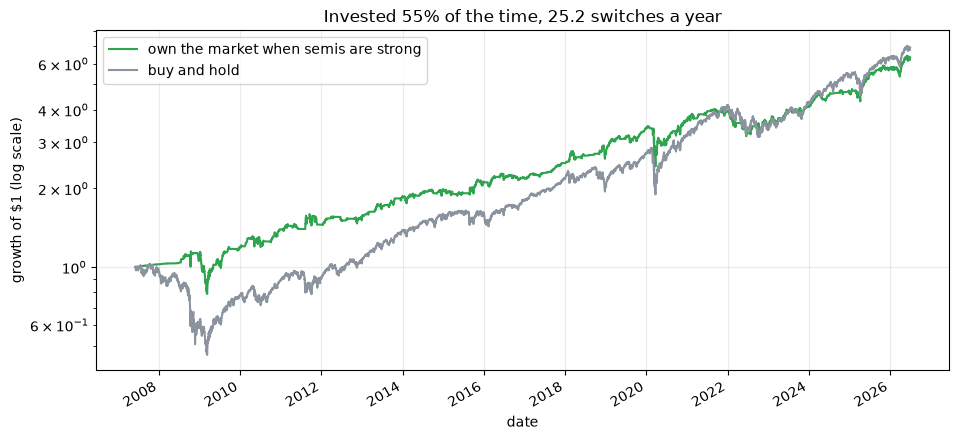

rule  CAGR +10.19%  Sharpe +0.74  maxDD -31.4%
hold  CAGR +10.70%  Sharpe +0.61  maxDD -55.2%


In [4]:
rule = st.timing_rule(common, data.CANARY, data.MARKET, data.CASH,
                      lookback=21, cost_bps=2.0)
curves = pd.DataFrame({
    "own the market when semis are strong": (1 + rule["returns"]).cumprod(),
    "buy and hold": (1 + common[data.MARKET].reindex(rule["returns"].index)).cumprod(),
})
fig, ax = plt.subplots(figsize=(11, 5))
curves.plot(ax=ax, logy=True, color=["#2ea44f", "#8b949e"])
ax.set_ylabel("growth of $1 (log scale)"); ax.legend(title="")
ax.set_title(f"Invested {rule['time_invested']:.0%} of the time, "
             f"{rule['switches_per_year']:.1f} switches a year")
plt.show()
print(f"rule  CAGR {rule['strategy']['cagr']:+.2%}  Sharpe {rule['strategy']['sharpe']:+.2f}  "
      f"maxDD {rule['strategy']['max_dd']:.1%}")
print(f"hold  CAGR {rule['buy_hold']['cagr']:+.2%}  Sharpe {rule['buy_hold']['sharpe']:+.2f}  "
      f"maxDD {rule['buy_hold']['max_dd']:.1%}")

## 4 · The control that matters

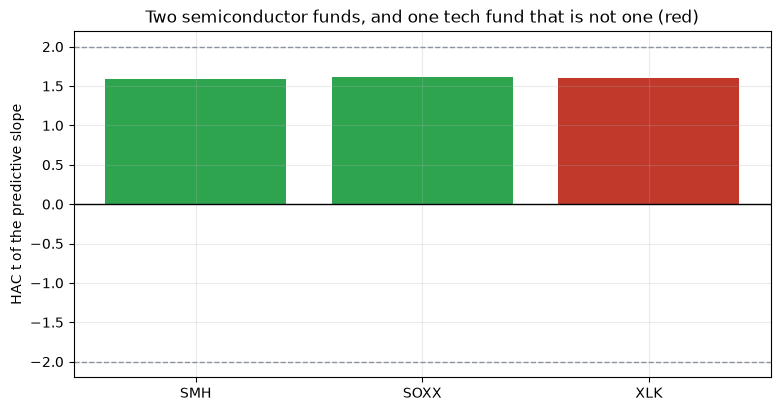

,beta,t,r2,cagr_gap,sharpe_gap,t_gap,time_invested
canary,,,,,,,
SMH,2.3490,1.5885,0.0104,-0.0051,0.1298,-0.4713,0.5457
SOXX,2.3022,1.6082,0.0112,-0.0004,0.1658,-0.3116,0.5309
XLK,5.2007,1.5959,0.0139,-0.0017,0.1388,-0.3577,0.5330


In [5]:
peers = st.peer_agreement(common, data.MARKET, data.CASH,
                          [data.CANARY] + list(data.PEERS), lookback=21, horizon=21)
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2ea44f" if c != "XLK" else "#c0392b" for c in peers.index]
ax.bar(peers.index, peers["t"], color=colors)
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, color="#8b949e", ls="--", lw=1)
ax.set_ylabel("HAC t of the predictive slope")
ax.set_title("Two semiconductor funds, and one tech fund that is not one (red)")
plt.show()
peers.round(4)

> \U0001F52C **For the quants.** If the red bar is as tall as the green ones, the story is not
> about semiconductors. That is the single most informative comparison in the study.

## 5 · The verdict

**Signal: Weak.** Once the market factor is regressed out, the canary is much quieter than the folklore. At lag 1 the semiconductor residual leads the market with correlation **+0.044** while the market leads it by -0.088 — a difference of **+0.132**. The headline predictive regression (trailing 21-day residual → next 21-day market return) gives a slope of +2.35 with HAC *t* = **+1.59** and an R² of 1.044%; **0 of 2** semiconductor funds clear |*t*| = 2, and **7** of the 12 lookback × horizon cells do, against 0.6 expected by luck. The non-semiconductor control (XLK) scores +1.60 — if the effect were about chips rather than about tech, that number should be small.

**Tradability: Fragile.** The rule — own the market while the canary's trailing relative strength is positive, hold bills otherwise — was invested 55% of the time, switched 25.2 times a year, and returned **+10.19%/yr** against **+10.70%/yr** for simply owning the market (-0.51%/yr, Sharpe +0.74 vs +0.61, HAC *t* on the daily difference -0.47). Its drawdown was -31.4% against -55.2% — the risk reduction is real; the return is not.

## 6 · Going further \U0001F6AA

- **The fundamental version.** Book-to-bill and semiconductor billings lead the cycle far more
  convincingly than prices do; that is a data problem, not a market one.
- **Firm-level links** (Cohen & Frazzini 2008) are where economic-link predictability actually
  lives — customers and suppliers, not sector indices.
- **Concentration.** In recent years one company dominates both semiconductor funds, so the
  test increasingly asks whether *one stock* leads the market.